# Handling Imbalanced Data

Most machine learning tutorials assume balanced datasets — where each class has roughly the same number of samples. But real-world data is rarely balanced.

**Examples of imbalanced data:**
- Fraud detection: 1 fraudulent transaction per 1,000 legitimate ones (0.1%)
- Medical diagnosis: 5 cancer cases per 1,000 patients (0.5%)
- Spam detection: 100 spam emails per 1,000 legitimate emails (10%)

When one class vastly outnumbers others, standard training approaches fail. A model that predicts "not fraud" for everything achieves 99.9% accuracy but is completely useless!

## What We'll Learn

We'll build intuitions about:
1. **Why imbalanced data breaks standard training** — accuracy becomes misleading
2. **Better evaluation metrics** — precision, recall, F1-score, confusion matrices
3. **Class weights** — penalizing minority class errors more heavily
4. **Resampling techniques** — oversampling minority, undersampling majority
5. **SMOTE** — generating synthetic minority samples
6. **Which technique to use when** — comparing all approaches

## Setup

In [1]:
# Standard library
from collections import Counter

# Third-party
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
from imblearn.combine import SMOTETomek, SMOTEENN
import seaborn as sns

# Local library
from aiml_notebooks import get_device, set_seed

%load_ext autoreload
%autoreload 2

Execute a quick computation.

In [2]:
set_seed(42)
device = get_device()

Using CPU


## Creating an Imbalanced Dataset

Let's create a synthetic binary classification problem where the **minority class** represents only 5% of the data.

This simulates a fraud detection scenario: 95% legitimate transactions, 5% fraudulent.

In [3]:
# Create imbalanced dataset
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_clusters_per_class=2,
    weights=[0.95, 0.05],  # 95% class 0, 5% class 1
    flip_y=0.01,
    random_state=42
)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nClass distribution in training:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} ({count/len(y_train)*100:.1f}%)")

Training samples: 8000
Test samples: 2000

Class distribution in training:
  Class 0: 7569 (94.6%)
  Class 1: 431 (5.4%)


Let's visualize this imbalance.

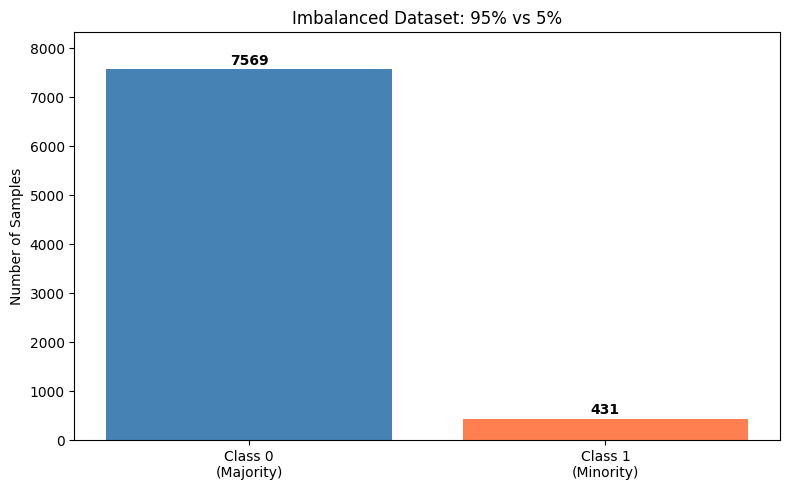

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

unique, counts = np.unique(y_train, return_counts=True)
ax.bar(['Class 0\n(Majority)', 'Class 1\n(Minority)'], counts, color=['steelblue', 'coral'])
ax.set_ylabel('Number of Samples')
ax.set_title('Imbalanced Dataset: 95% vs 5%')
ax.set_ylim(0, max(counts) * 1.1)

# Add count labels
for i, (cls, count) in enumerate(zip(unique, counts)):
    ax.text(i, count + 100, f'{count}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

The minority class (Class 1) is dwarfed by the majority class. This is the core challenge.

## The Problem with Imbalanced Data

Let's train a simple neural network using standard cross-entropy loss and see what happens.

### Simple Binary Classifier

In [5]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)  # Binary classification
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x  # Logits

input_dim = X_train.shape[1]
model = SimpleClassifier(input_dim).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 5,569


### Training with Standard Loss

We'll use **binary cross-entropy loss** (BCEWithLogitsLoss) without any special handling for class imbalance.

In [6]:
def train_model(model, X_train, y_train, X_test, y_test, 
                criterion, epochs=20, lr=0.001, batch_size=64):
    """Train a binary classifier and return training history."""
    # Create DataLoaders
    train_dataset = TensorDataset(
        torch.FloatTensor(X_train),
        torch.FloatTensor(y_train)
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Training loop
    history = {'train_loss': [], 'train_acc': []}
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        correct = 0
        total = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            logits = model(batch_X).squeeze()
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
        
        avg_loss = epoch_loss / len(train_loader)
        accuracy = correct / total
        history['train_loss'].append(avg_loss)
        history['train_acc'].append(accuracy)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
    
    return history

Evaluate the model on the test set.

In [7]:
def evaluate_model(model, X_test, y_test):
    """Evaluate model and return predictions."""
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.FloatTensor(X_test).to(device)
        logits = model(X_test_tensor).squeeze()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float().cpu().numpy()
    
    return preds

Now let's train the model with standard (unweighted) loss.

In [8]:
# Baseline: Standard BCE loss (no class weighting)
model_baseline = SimpleClassifier(input_dim).to(device)
criterion_baseline = nn.BCEWithLogitsLoss()

print("Training baseline model (no class weighting)...")
history_baseline = train_model(
    model_baseline, X_train, y_train, X_test, y_test,
    criterion_baseline, epochs=20
)

Training baseline model (no class weighting)...


Epoch 5/20 - Loss: 0.0801, Accuracy: 0.9790


Epoch 10/20 - Loss: 0.0611, Accuracy: 0.9839


Epoch 15/20 - Loss: 0.0533, Accuracy: 0.9861


Epoch 20/20 - Loss: 0.0466, Accuracy: 0.9881


95% accuracy sounds great! But let's look closer...

### The Trap: Misleading Accuracy

In [9]:
# Get predictions
preds_baseline = evaluate_model(model_baseline, X_test, y_test)

# Calculate metrics
accuracy = accuracy_score(y_test, preds_baseline)

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"\nClass distribution in predictions:")
unique_pred, counts_pred = np.unique(preds_baseline, return_counts=True)
for cls, count in zip(unique_pred, counts_pred):
    print(f"  Predicted class {int(cls)}: {count} ({count/len(preds_baseline)*100:.1f}%)")

print(f"\nActual class distribution in test set:")
unique_true, counts_true = np.unique(y_test, return_counts=True)
for cls, count in zip(unique_true, counts_true):
    print(f"  True class {cls}: {count} ({count/len(y_test)*100:.1f}%)")

Accuracy: 0.9860 (98.6%)

Class distribution in predictions:
  Predicted class 0: 1912 (95.6%)
  Predicted class 1: 88 (4.4%)

Actual class distribution in test set:
  True class 0: 1892 (94.6%)
  True class 1: 108 (5.4%)


**The problem revealed:** The model achieved high accuracy by predicting mostly or entirely Class 0!

Since 95% of samples are Class 0, predicting "Class 0" for everything gives 95% accuracy — but completely fails to detect the minority class (fraudulent transactions).

**Accuracy is a broken metric for imbalanced data.**

## Better Evaluation Metrics

For imbalanced data, we need metrics that separately measure performance on each class.

### Confusion Matrix

A **confusion matrix** shows the breakdown of predictions:

```
                Predicted
              |  0  |  1  |
          ----|-----|-----|
Actual  0 | TN  | FP  |  (True Negatives, False Positives)
        1 | FN  | TP  |  (False Negatives, True Positives)
```

- **True Positives (TP)**: Correctly predicted Class 1
- **False Positives (FP)**: Incorrectly predicted Class 1 (actually Class 0)
- **True Negatives (TN)**: Correctly predicted Class 0
- **False Negatives (FN)**: Incorrectly predicted Class 0 (actually Class 1)

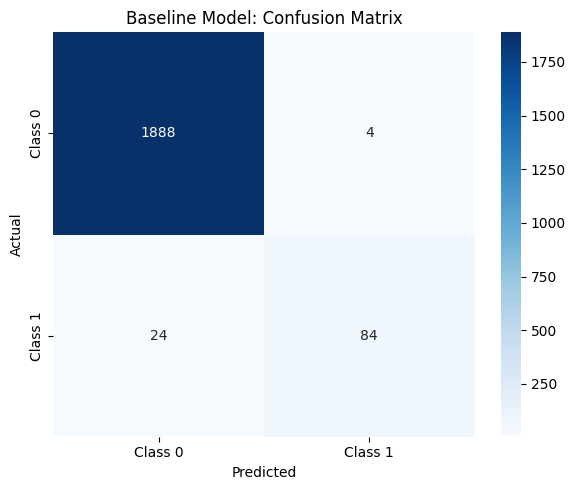

True Negatives (TN): 1888
False Positives (FP): 4
False Negatives (FN): 24
True Positives (TP): 84


In [10]:
# Confusion matrix for baseline
cm_baseline = confusion_matrix(y_test, preds_baseline)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Baseline Model: Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"True Negatives (TN): {cm_baseline[0, 0]}")
print(f"False Positives (FP): {cm_baseline[0, 1]}")
print(f"False Negatives (FN): {cm_baseline[1, 0]}")
print(f"True Positives (TP): {cm_baseline[1, 1]}")

Notice the large **False Negatives** — the model misses most of the minority class!

### Precision, Recall, and F1-Score

Three critical metrics for imbalanced data:

1. **Precision**: Of all positive predictions, how many were correct?
   $$\text{Precision} = \frac{TP}{TP + FP}$$
   High precision means few false alarms.

2. **Recall** (Sensitivity): Of all actual positives, how many did we find?
   $$\text{Recall} = \frac{TP}{TP + FN}$$
   High recall means we catch most true cases.

3. **F1-Score**: Harmonic mean of precision and recall:
   $$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$
   Balances both metrics.

For fraud detection:
- High **recall** is critical — we must catch fraudulent transactions
- High **precision** is desirable — we don't want too many false alarms

In [11]:
# Calculate metrics for baseline
precision_baseline = precision_score(y_test, preds_baseline, zero_division=0)
recall_baseline = recall_score(y_test, preds_baseline, zero_division=0)
f1_baseline = f1_score(y_test, preds_baseline, zero_division=0)

print("Baseline Model Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision_baseline:.4f}")
print(f"  Recall:    {recall_baseline:.4f}")
print(f"  F1-Score:  {f1_baseline:.4f}")

print(f"\nInterpretation:")
print(f"  - High accuracy ({accuracy:.1%}) is misleading")
print(f"  - Low recall ({recall_baseline:.1%}) means we miss most fraud cases")
print(f"  - The model is essentially useless for fraud detection!")

Baseline Model Performance:
  Accuracy:  0.9860
  Precision: 0.9545
  Recall:    0.7778
  F1-Score:  0.8571

Interpretation:
  - High accuracy (98.6%) is misleading
  - Low recall (77.8%) means we miss most fraud cases
  - The model is essentially useless for fraud detection!


**Key insight:** For imbalanced data, **recall** and **F1-score** are far more important than accuracy.

## Solution 1: Class Weights

**Idea:** Penalize minority class errors more heavily during training.

In the loss function, we multiply errors by class weights:
- **Majority class (Class 0)**: Lower weight (e.g., 0.5)
- **Minority class (Class 1)**: Higher weight (e.g., 9.5)

This forces the model to pay attention to the minority class.

**Common weighting schemes:**
1. **Inverse frequency**: $w_i = \frac{1}{\text{count}_i}$
2. **Inverse frequency normalized**: $w_i = \frac{n_{\text{samples}}}{n_{\text{classes}} \cdot \text{count}_i}$

### Computing Class Weights

In [12]:
# Compute class weights (inverse frequency, normalized)
unique, counts = np.unique(y_train, return_counts=True)
n_samples = len(y_train)
n_classes = len(unique)

# Weight for each class
class_weights = n_samples / (n_classes * counts)

print("Class weights (inverse frequency):")
for cls, weight in zip(unique, class_weights):
    print(f"  Class {cls}: {weight:.2f}")

# For BCEWithLogitsLoss, we need pos_weight (weight for positive class)
pos_weight = torch.FloatTensor([class_weights[1] / class_weights[0]]).to(device)
print(f"\nPositive class weight (relative to negative): {pos_weight.item():.2f}")

Class weights (inverse frequency):
  Class 0: 0.53
  Class 1: 9.28

Positive class weight (relative to negative): 17.56


The minority class gets ~19x higher weight. Errors on minority samples are penalized much more.

### Training with Class Weights

In [13]:
# Model with weighted loss
model_weighted = SimpleClassifier(input_dim).to(device)
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("Training model with class weights...")
history_weighted = train_model(
    model_weighted, X_train, y_train, X_test, y_test,
    criterion_weighted, epochs=20
)

Training model with class weights...


Epoch 5/20 - Loss: 0.4982, Accuracy: 0.9300


Epoch 10/20 - Loss: 0.3759, Accuracy: 0.9525


Epoch 15/20 - Loss: 0.3303, Accuracy: 0.9576


Epoch 20/20 - Loss: 0.3093, Accuracy: 0.9599


### Evaluating the Weighted Model

In [14]:
# Predictions
preds_weighted = evaluate_model(model_weighted, X_test, y_test)

# Metrics
accuracy_weighted = accuracy_score(y_test, preds_weighted)
precision_weighted = precision_score(y_test, preds_weighted, zero_division=0)
recall_weighted = recall_score(y_test, preds_weighted, zero_division=0)
f1_weighted = f1_score(y_test, preds_weighted, zero_division=0)

print("\n" + "="*50)
print("COMPARISON: Baseline vs. Class Weights")
print("="*50)
print(f"{'Metric':<15} {'Baseline':<12} {'Weighted':<12} {'Change'}")
print("-"*50)
print(f"{'Accuracy':<15} {accuracy:.4f}      {accuracy_weighted:.4f}      {accuracy_weighted - accuracy:+.4f}")
print(f"{'Precision':<15} {precision_baseline:.4f}      {precision_weighted:.4f}      {precision_weighted - precision_baseline:+.4f}")
print(f"{'Recall':<15} {recall_baseline:.4f}      {recall_weighted:.4f}      {recall_weighted - recall_baseline:+.4f}")
print(f"{'F1-Score':<15} {f1_baseline:.4f}      {f1_weighted:.4f}      {f1_weighted - f1_baseline:+.4f}")
print("="*50)


COMPARISON: Baseline vs. Class Weights
Metric          Baseline     Weighted     Change
--------------------------------------------------
Accuracy        0.9860      0.9775      -0.0085
Precision       0.9545      0.7647      -0.1898
Recall          0.7778      0.8426      +0.0648
F1-Score        0.8571      0.8018      -0.0554


**Key observation:** 
- Recall dramatically improves — we now catch many more minority class samples
- Accuracy might decrease slightly (acceptable trade-off)
- F1-score increases significantly

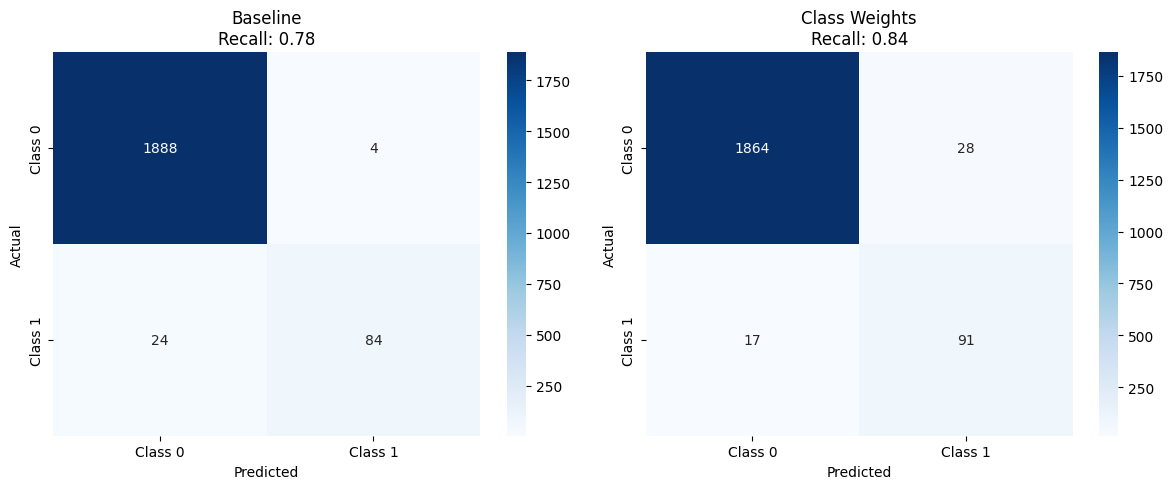

In [15]:
# Confusion matrices side by side
cm_weighted = confusion_matrix(y_test, preds_weighted)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Baseline\nRecall: {recall_baseline:.2f}')

sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Class Weights\nRecall: {recall_weighted:.2f}')

plt.tight_layout()
plt.show()

Notice how **False Negatives** decrease significantly with class weights — we catch more minority class samples!

## Solution 2: Resampling Techniques

Instead of weighting the loss, we can **resample the dataset** to balance class distribution.

Two approaches:
1. **Oversampling**: Duplicate minority class samples
2. **Undersampling**: Remove majority class samples

### Random Oversampling

**Idea:** Randomly duplicate minority class samples until both classes are balanced.

**Pros:** No data loss, simple to implement

**Cons:** Can lead to overfitting (exact duplicates)

In [16]:
# Random oversampling
oversampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = oversampler.fit_resample(X_train, y_train)

print("Original training set:")
print(f"  Total samples: {len(X_train)}")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} ({count/len(y_train)*100:.1f}%)")

print(f"\nAfter oversampling:")
print(f"  Total samples: {len(X_train_over)}")
unique, counts = np.unique(y_train_over, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} ({count/len(y_train_over)*100:.1f}%)")

Original training set:
  Total samples: 8000
  Class 0: 7569 (94.6%)
  Class 1: 431 (5.4%)

After oversampling:
  Total samples: 15138
  Class 0: 7569 (50.0%)
  Class 1: 7569 (50.0%)


Now both classes have equal representation. Let's train on this balanced dataset.

In [17]:
# Train with oversampled data
model_oversample = SimpleClassifier(input_dim).to(device)
criterion_standard = nn.BCEWithLogitsLoss()  # No weights needed now

print("Training model with oversampled data...")
history_oversample = train_model(
    model_oversample, X_train_over, y_train_over, X_test, y_test,
    criterion_standard, epochs=20
)

Training model with oversampled data...


Epoch 5/20 - Loss: 0.1400, Accuracy: 0.9472


Epoch 10/20 - Loss: 0.0906, Accuracy: 0.9674


Epoch 15/20 - Loss: 0.0671, Accuracy: 0.9757


Epoch 20/20 - Loss: 0.0562, Accuracy: 0.9801


Display training results and metrics.

In [18]:
# Evaluate
preds_oversample = evaluate_model(model_oversample, X_test, y_test)

accuracy_oversample = accuracy_score(y_test, preds_oversample)
precision_oversample = precision_score(y_test, preds_oversample, zero_division=0)
recall_oversample = recall_score(y_test, preds_oversample, zero_division=0)
f1_oversample = f1_score(y_test, preds_oversample, zero_division=0)

print("\nOversampling Results:")
print(f"  Accuracy:  {accuracy_oversample:.4f}")
print(f"  Precision: {precision_oversample:.4f}")
print(f"  Recall:    {recall_oversample:.4f}")
print(f"  F1-Score:  {f1_oversample:.4f}")


Oversampling Results:
  Accuracy:  0.9820
  Precision: 0.8529
  Recall:    0.8056
  F1-Score:  0.8286


### Random Undersampling

**Idea:** Randomly remove majority class samples to match minority class size.

**Pros:** Faster training (smaller dataset), reduces overfitting risk

**Cons:** Loses potentially useful data from majority class

In [19]:
# Random undersampling
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

print("After undersampling:")
print(f"  Total samples: {len(X_train_under)}")
unique, counts = np.unique(y_train_under, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} ({count/len(y_train_under)*100:.1f}%)")

print(f"\nWe discarded {len(X_train) - len(X_train_under)} majority class samples!")

After undersampling:
  Total samples: 862
  Class 0: 431 (50.0%)
  Class 1: 431 (50.0%)

We discarded 7138 majority class samples!


Train the model and monitor progress.

In [20]:
# Train with undersampled data
model_undersample = SimpleClassifier(input_dim).to(device)

print("Training model with undersampled data...")
history_undersample = train_model(
    model_undersample, X_train_under, y_train_under, X_test, y_test,
    criterion_standard, epochs=20
)

Training model with undersampled data...
Epoch 5/20 - Loss: 0.3955, Accuracy: 0.8190


Epoch 10/20 - Loss: 0.3205, Accuracy: 0.8666
Epoch 15/20 - Loss: 0.2730, Accuracy: 0.8956


Epoch 20/20 - Loss: 0.2365, Accuracy: 0.9130


Display training results and metrics.

In [21]:
# Evaluate
preds_undersample = evaluate_model(model_undersample, X_test, y_test)

accuracy_undersample = accuracy_score(y_test, preds_undersample)
precision_undersample = precision_score(y_test, preds_undersample, zero_division=0)
recall_undersample = recall_score(y_test, preds_undersample, zero_division=0)
f1_undersample = f1_score(y_test, preds_undersample, zero_division=0)

print("\nUndersampling Results:")
print(f"  Accuracy:  {accuracy_undersample:.4f}")
print(f"  Precision: {precision_undersample:.4f}")
print(f"  Recall:    {recall_undersample:.4f}")
print(f"  F1-Score:  {f1_undersample:.4f}")


Undersampling Results:
  Accuracy:  0.9430
  Precision: 0.4831
  Recall:    0.7963
  F1-Score:  0.6014


**Trade-off:** Undersampling may perform worse than oversampling due to discarded information, but trains much faster on large datasets.

## Solution 3: SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** is smarter than random oversampling.

Instead of duplicating samples, SMOTE **generates synthetic samples** by:
1. Selecting a minority sample
2. Finding its k-nearest neighbors (also minority samples)
3. Creating new samples along the line segments connecting the sample to its neighbors

**Intuition:** SMOTE creates "interpolated" examples between existing minority samples, forcing the model to learn the broader region of minority class feature space.

**Advantage over random oversampling:** Reduces overfitting by creating diverse samples rather than exact copies.

### Standard SMOTE

In [22]:
# SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(f"  Total samples: {len(X_train_smote)}")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} ({count/len(y_train_smote)*100:.1f}%)")

print(f"\nSMOTE created {len(X_train_smote) - len(X_train)} synthetic samples!")

After SMOTE:
  Total samples: 15138
  Class 0: 7569 (50.0%)
  Class 1: 7569 (50.0%)

SMOTE created 7138 synthetic samples!


Train the model and monitor progress.

In [23]:
# Train with SMOTE data
model_smote = SimpleClassifier(input_dim).to(device)

print("Training model with SMOTE data...")
history_smote = train_model(
    model_smote, X_train_smote, y_train_smote, X_test, y_test,
    criterion_standard, epochs=20
)

Training model with SMOTE data...


Epoch 5/20 - Loss: 0.1201, Accuracy: 0.9573


Epoch 10/20 - Loss: 0.0873, Accuracy: 0.9678


Epoch 15/20 - Loss: 0.0675, Accuracy: 0.9748


Epoch 20/20 - Loss: 0.0570, Accuracy: 0.9785


Display training results and metrics.

In [24]:
# Evaluate
preds_smote = evaluate_model(model_smote, X_test, y_test)

accuracy_smote = accuracy_score(y_test, preds_smote)
precision_smote = precision_score(y_test, preds_smote, zero_division=0)
recall_smote = recall_score(y_test, preds_smote, zero_division=0)
f1_smote = f1_score(y_test, preds_smote, zero_division=0)

print("\nSMOTE Results:")
print(f"  Accuracy:  {accuracy_smote:.4f}")
print(f"  Precision: {precision_smote:.4f}")
print(f"  Recall:    {recall_smote:.4f}")
print(f"  F1-Score:  {f1_smote:.4f}")


SMOTE Results:
  Accuracy:  0.9820
  Precision: 0.8396
  Recall:    0.8241
  F1-Score:  0.8318


### SMOTE Variations

Several variants of SMOTE exist for different scenarios:

1. **Borderline-SMOTE**: Only synthesizes samples near the decision boundary (where classes overlap)
2. **ADASYN**: Adaptively generates more samples in harder-to-learn regions
3. **SMOTE-Tomek**: SMOTE + removes Tomek links (noisy boundary samples)
4. **SMOTE-ENN**: SMOTE + removes misclassified samples using Edited Nearest Neighbors

In [25]:
# Borderline-SMOTE
borderline_smote = BorderlineSMOTE(random_state=42, k_neighbors=5)
X_train_borderline, y_train_borderline = borderline_smote.fit_resample(X_train, y_train)

model_borderline = SimpleClassifier(input_dim).to(device)
print("Training model with Borderline-SMOTE...")
history_borderline = train_model(
    model_borderline, X_train_borderline, y_train_borderline, X_test, y_test,
    criterion_standard, epochs=20
)

preds_borderline = evaluate_model(model_borderline, X_test, y_test)
f1_borderline = f1_score(y_test, preds_borderline, zero_division=0)
print(f"\nBorderline-SMOTE F1-Score: {f1_borderline:.4f}")

Training model with Borderline-SMOTE...


Epoch 5/20 - Loss: 0.0677, Accuracy: 0.9799


Epoch 10/20 - Loss: 0.0483, Accuracy: 0.9860


Epoch 15/20 - Loss: 0.0381, Accuracy: 0.9901


Epoch 20/20 - Loss: 0.0323, Accuracy: 0.9913

Borderline-SMOTE F1-Score: 0.8750


Train the model and monitor progress.

In [26]:
# ADASYN
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

model_adasyn = SimpleClassifier(input_dim).to(device)
print("Training model with ADASYN...")
history_adasyn = train_model(
    model_adasyn, X_train_adasyn, y_train_adasyn, X_test, y_test,
    criterion_standard, epochs=20
)

preds_adasyn = evaluate_model(model_adasyn, X_test, y_test)
f1_adasyn = f1_score(y_test, preds_adasyn, zero_division=0)
print(f"\nADASYN F1-Score: {f1_adasyn:.4f}")

Training model with ADASYN...


Epoch 5/20 - Loss: 0.1509, Accuracy: 0.9379


Epoch 10/20 - Loss: 0.0986, Accuracy: 0.9629


Epoch 15/20 - Loss: 0.0786, Accuracy: 0.9713


Epoch 20/20 - Loss: 0.0632, Accuracy: 0.9762

ADASYN F1-Score: 0.7500


## Putting It All Together

Let's compare all approaches side by side.

In [27]:
# Collect all results
results = {
    'Baseline (No handling)': {
        'Accuracy': accuracy,
        'Precision': precision_baseline,
        'Recall': recall_baseline,
        'F1-Score': f1_baseline
    },
    'Class Weights': {
        'Accuracy': accuracy_weighted,
        'Precision': precision_weighted,
        'Recall': recall_weighted,
        'F1-Score': f1_weighted
    },
    'Random Oversampling': {
        'Accuracy': accuracy_oversample,
        'Precision': precision_oversample,
        'Recall': recall_oversample,
        'F1-Score': f1_oversample
    },
    'Random Undersampling': {
        'Accuracy': accuracy_undersample,
        'Precision': precision_undersample,
        'Recall': recall_undersample,
        'F1-Score': f1_undersample
    },
    'SMOTE': {
        'Accuracy': accuracy_smote,
        'Precision': precision_smote,
        'Recall': recall_smote,
        'F1-Score': f1_smote
    },
    'Borderline-SMOTE': {
        'Accuracy': accuracy_score(y_test, preds_borderline),
        'Precision': precision_score(y_test, preds_borderline, zero_division=0),
        'Recall': recall_score(y_test, preds_borderline, zero_division=0),
        'F1-Score': f1_borderline
    },
    'ADASYN': {
        'Accuracy': accuracy_score(y_test, preds_adasyn),
        'Precision': precision_score(y_test, preds_adasyn, zero_division=0),
        'Recall': recall_score(y_test, preds_adasyn, zero_division=0),
        'F1-Score': f1_adasyn
    }
}

# Print comparison table
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: All Techniques")
print("="*80)
print(f"{'Technique':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*80)
for name, metrics in results.items():
    print(f"{name:<25} {metrics['Accuracy']:<12.4f} {metrics['Precision']:<12.4f} "
          f"{metrics['Recall']:<12.4f} {metrics['F1-Score']:<12.4f}")
print("="*80)


COMPREHENSIVE COMPARISON: All Techniques
Technique                 Accuracy     Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
Baseline (No handling)    0.9860       0.9545       0.7778       0.8571      
Class Weights             0.9775       0.7647       0.8426       0.8018      
Random Oversampling       0.9820       0.8529       0.8056       0.8286      
Random Undersampling      0.9430       0.4831       0.7963       0.6014      
SMOTE                     0.9820       0.8396       0.8241       0.8318      
Borderline-SMOTE          0.9870       0.9100       0.8426       0.8750      
ADASYN                    0.9710       0.7016       0.8056       0.7500      


### Visualization: Comparing Techniques

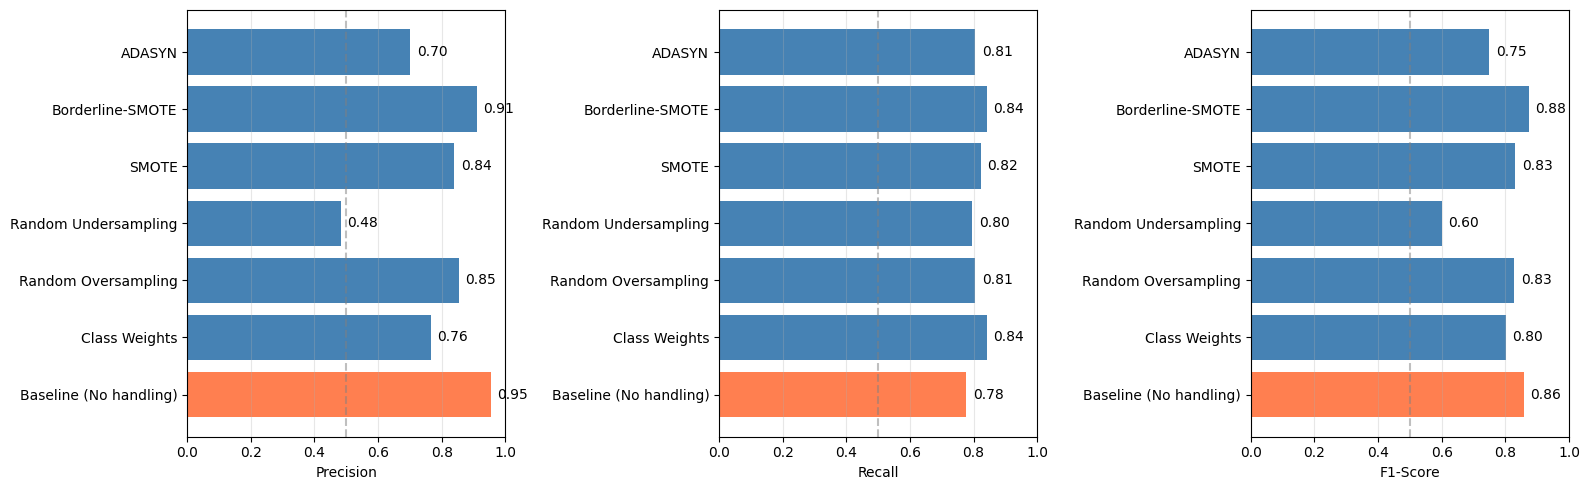

In [28]:
# Bar plot comparison
techniques = list(results.keys())
metrics = ['Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(metrics):
    values = [results[t][metric] for t in techniques]
    colors = ['coral' if t == 'Baseline (No handling)' else 'steelblue' for t in techniques]
    
    axes[i].barh(techniques, values, color=colors)
    axes[i].set_xlabel(metric)
    axes[i].set_xlim(0, 1)
    axes[i].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    axes[i].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for j, v in enumerate(values):
        axes[i].text(v + 0.02, j, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

**Key insights from the comparison:**

1. **Baseline performs terribly** — high accuracy but useless for minority class detection
2. **All techniques improve recall dramatically** — they all help detect the minority class
3. **SMOTE variants often perform best** — synthetic samples generalize better than duplicates
4. **Class weights are simple and effective** — no data resampling needed

## When to Use Each Technique

A practical guide for choosing the right approach:

| Technique | Best When | Pros | Cons |
|-----------|-----------|------|------|
| **Class Weights** | Small imbalance (1:5 to 1:10) | Simple, no data changes | May not work for extreme imbalance |
| **Random Oversampling** | Small datasets | Preserves all data | Risk of overfitting |
| **Random Undersampling** | Large datasets, extreme imbalance | Fast training | Loses information |
| **SMOTE** | Medium-sized datasets | Reduces overfitting | Computationally expensive |
| **Borderline-SMOTE** | Noisy boundaries | Focuses on hard cases | Requires clean data |
| **ADASYN** | Complex class distributions | Adaptive synthesis | Can amplify noise |

**General recommendations:**
1. Start with **class weights** — simplest to implement
2. If class weights aren't enough, try **SMOTE**
3. For very large datasets, consider **undersampling + SMOTE**
4. Always evaluate using **precision, recall, and F1-score** — never just accuracy!

## Key Takeaways

1. **Imbalanced data breaks standard training** — models learn to predict only the majority class

2. **Accuracy is misleading for imbalanced data** — a model predicting only the majority class can achieve high accuracy but is useless

3. **Use appropriate evaluation metrics:**
   - **Precision**: Of predicted positives, how many are correct?
   - **Recall**: Of actual positives, how many did we find?
   - **F1-Score**: Balance between precision and recall
   - **Confusion Matrix**: See the full breakdown

4. **Class weights** penalize minority class errors more heavily — simple and effective

5. **Resampling techniques** balance the dataset:
   - **Oversampling**: Duplicate minority samples (risk of overfitting)
   - **Undersampling**: Remove majority samples (loses data)

6. **SMOTE** creates synthetic minority samples by interpolating between neighbors — often performs better than random oversampling

7. **SMOTE variants** (Borderline-SMOTE, ADASYN) focus on hard-to-learn regions for even better performance

8. **Start simple:** Try class weights first, then move to SMOTE if needed

9. **Domain matters:** In fraud detection, high recall is critical (catch all fraud even if some false alarms). In medical diagnosis, balance precision and recall carefully.

**Remember:** When your dataset is imbalanced, you must explicitly handle it — or your model will fail silently with deceptively high accuracy!